In [2]:
from transformer_lens import HookedTransformer

/Users/jesanahammed/Transformer-interpretability/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [23]:
prompt = "The sky is blue and the grass is "

In [24]:
model = HookedTransformer.from_pretrained('EleutherAI/pythia-14m')

Loaded pretrained model EleutherAI/pythia-14m into HookedTransformer


In [26]:
tokens = model.to_tokens(prompt)
print(tokens)
print(prompt)

tensor([[    0,   510,  8467,   310,  4797,   285,   253, 10583,   310,   209]],
       device='mps:0')
The sky is blue and the grass is 


In [27]:
logits, cache = model.run_with_cache(tokens)

In [46]:
print(logits.shape)
print(cache)
print(len(cache))

torch.Size([1, 10, 50304])
ActivationCache with keys ['hook_embed', 'blocks.0.hook_resid_pre', 'blocks.0.ln1.hook_scale', 'blocks.0.ln1.hook_normalized', 'blocks.0.attn.hook_q', 'blocks.0.attn.hook_k', 'blocks.0.attn.hook_v', 'blocks.0.attn.hook_rot_q', 'blocks.0.attn.hook_rot_k', 'blocks.0.attn.hook_attn_scores', 'blocks.0.attn.hook_pattern', 'blocks.0.attn.hook_z', 'blocks.0.hook_attn_out', 'blocks.0.ln2.hook_scale', 'blocks.0.ln2.hook_normalized', 'blocks.0.mlp.hook_pre', 'blocks.0.mlp.hook_post', 'blocks.0.hook_mlp_out', 'blocks.0.hook_resid_post', 'blocks.1.hook_resid_pre', 'blocks.1.ln1.hook_scale', 'blocks.1.ln1.hook_normalized', 'blocks.1.attn.hook_q', 'blocks.1.attn.hook_k', 'blocks.1.attn.hook_v', 'blocks.1.attn.hook_rot_q', 'blocks.1.attn.hook_rot_k', 'blocks.1.attn.hook_attn_scores', 'blocks.1.attn.hook_pattern', 'blocks.1.attn.hook_z', 'blocks.1.hook_attn_out', 'blocks.1.ln2.hook_scale', 'blocks.1.ln2.hook_normalized', 'blocks.1.mlp.hook_pre', 'blocks.1.mlp.hook_post', 'bl

In [29]:
W_U = model.unembed.W_U
top_k = 5
print(W_U.shape)

torch.Size([128, 50304])


In [38]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import torch.nn.functional as F

In [37]:
layers_probs = []

In [40]:
# Embeding Layer
resid = cache["hook_embed"]
layer_logits = resid @ W_U
probs = F.softmax(layer_logits, dim=-1)[0, -1]
last_token_logits = layer_logits[0, -1]
topk_values, topk_indices = torch.topk(last_token_logits, top_k)
topk_tokens = model.to_str_tokens(topk_indices)
layers_probs.append(probs[topk_indices].detach().cpu().numpy())

print("\nLayer 0 (Embedding):")
for t, v in zip(topk_tokens, topk_values):
    print(f"  {t} : {v.item():.4f}")


Layer 0 (Embedding):
  eLife : 0.5447
  "; : 0.4352
  "){ : 0.4310
  "); : 0.4309
   BytePtrFromString : 0.4127


In [41]:
# Trasformer Layer
for layer in range(model.cfg.n_layers):
    resid = cache[f"blocks.{layer}.hook_resid_post"]
    layer_logits = resid @ W_U
    probs = F.softmax(layer_logits, dim=-1)[0, -1]
    last_token_logits = layer_logits[0, -1]
    topk_values, topk_indices = torch.topk(last_token_logits, top_k)
    topk_tokens = model.to_str_tokens(topk_indices)
    layers_probs.append(probs[topk_indices].detach().cpu().numpy())

    print(f"\nLayer {layer+1}:")
    for t, v in zip(topk_tokens, topk_values):
        print(f"  {t} : {v.item():.4f}")



Layer 1:
  "? : 1.0574
  " : 1.0198
  ierung : 1.0138
  "?" : 0.9957
  plete : 0.9833

Layer 2:
  ische : 1.3023
  agna : 1.3004
  ubuntu : 1.2611
  chte : 1.2585
  ierung : 1.2178

Layer 3:
  - : 1.7635
   the : 1.7096
  " : 1.6424
   " : 1.5870
  ample : 1.5368

Layer 4:
  athe : 1.8047
  ft : 1.7965
  " : 1.7630
  </ : 1.7611
  *- : 1.7594

Layer 5:
  icing : 3.2250
  iced : 3.0445
  ching : 2.9083
  asma : 2.8476
  oidal : 2.4752

Layer 6:
  iced : 3.2704
  icing : 3.1068
  culate : 2.5937
  ump : 2.4524
  urn : 2.4134


In [43]:
# Final layer (actual model output)
final_logits = logits[0, -1]
probs = F.softmax(final_logits, dim=-1)
topk_values, topk_indices = torch.topk(final_logits, top_k)
topk_tokens = model.to_str_tokens(topk_indices)
layers_probs.append(probs[topk_indices].detach().cpu().numpy())

print("\nFinal Layer (Model Output):")
for t, v in zip(topk_tokens, topk_values):
    print(f"  {t} : {v.item():.4f}")


Final Layer (Model Output):
  
 : 17.0685
  iced : 16.4125
  icing : 16.3053
  urn : 13.6489
  ump : 13.4477


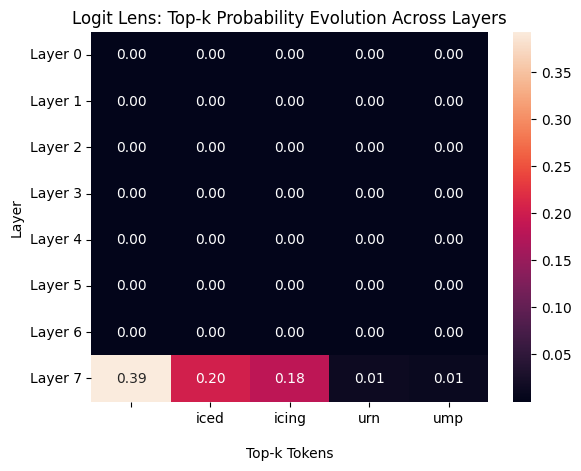

In [44]:
sns.heatmap(layers_probs, annot=True, fmt=".2f", xticklabels=topk_tokens,
            yticklabels=[f"Layer {i}" for i in range(len(layers_probs))])
plt.xlabel("Top-k Tokens")
plt.ylabel("Layer")
plt.title("Logit Lens: Top-k Probability Evolution Across Layers")
plt.show()


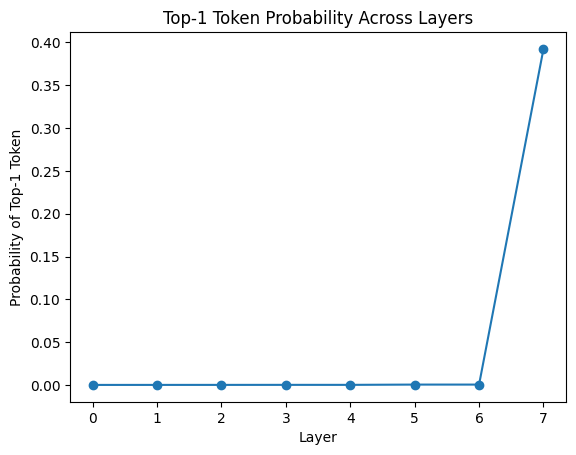

In [45]:
top1_probs = [F.softmax(cache["hook_embed"] @ W_U, dim=-1)[0, -1].max().item()]
for layer in range(model.cfg.n_layers):
    resid = cache[f"blocks.{layer}.hook_resid_post"]
    top1_probs.append(F.softmax(resid @ W_U, dim=-1)[0, -1].max().item())
top1_probs.append(F.softmax(logits[0, -1], dim=-1).max().item())

plt.plot(range(len(top1_probs)), top1_probs, marker='o')
plt.xlabel("Layer")
plt.ylabel("Probability of Top-1 Token")
plt.title("Top-1 Token Probability Across Layers")
plt.show()